In [1]:
import sys
sys.path.append('/home/ypguo/async-FL')
from paint.draw import *

In [2]:
main_dir = '/home/ypguo/async-FL/lambda_PK'
baseline_path_list = []

custom_order = ["lambda0", "lambda0.01","lambda0.02","lambda0.035"]

# 创建排序键函数
def custom_sort(item):
    # 对于列表中的项目，返回其索引
    for i, prefix in enumerate(custom_order):
        if item.split('-')[-2].endswith(prefix):
            return i
    # 对于不在列表中的项目，返回一个较大的数，使它们排在最后
    return len(custom_order)

for algo_dir in sorted(os.listdir(main_dir),key=custom_sort):
    path = os.path.join(main_dir, algo_dir)
    if os.path.isdir(path):
        baseline_path_list.append(path)

for path in baseline_path_list:
    parse_log_file(path)
    print("finished " + path.split("/")[-1])




Data saved to /home/ypguo/async-FL/lambda_PK/FedAGSA-lambda0-epsilon2/epoch_results.csv
finished FedAGSA-lambda0-epsilon2
Data saved to /home/ypguo/async-FL/lambda_PK/FedAGSA-lambda0.01-epsilon2/epoch_results.csv
finished FedAGSA-lambda0.01-epsilon2
Data saved to /home/ypguo/async-FL/lambda_PK/FedAGSA-lambda0.02-epsilon2/epoch_results.csv
finished FedAGSA-lambda0.02-epsilon2
Data saved to /home/ypguo/async-FL/lambda_PK/FedAGSA-lambda0.035-epsilon2/epoch_results.csv
finished FedAGSA-lambda0.035-epsilon2


In [3]:
# 示例调用
delay_model_path = '/home/ypguo/async-FL/src/clients_info/clients_info_dir0.5_cnn_delaymodel.csv'
# fedavg_epoch_result = '/home/ypguo/async-FL/src/results/Exp2025-FashionMNIST-Dir0.5/fedavg-cnn-dir0.5/epoch_results.csv'
for path in baseline_path_list:
    epoch_result_path = path + '/epoch_results.csv'
    output_csv_path = path + '/epoch_results_with_cumtime.csv'
    process_and_save_results(delay_model_path, epoch_result_path, output_csv_path)
    print("finished " + path.split("/")[-1])


    # 统计时延分布
    epoch_result = pd.read_csv(path + '/epoch_results_with_cumtime.csv')
    group_delay = sorted(epoch_result['sim_round_time'].value_counts().keys())
    group_info = pd.read_csv("/home/ypguo/async-FL/dir0.5_cnn-0.7-0.3_final1/group_info.csv")
    group_delay_fix = sorted(group_info['group_delay_time'].value_counts().keys())
    map_dict = {group_delay[i]: group_delay_fix[i] for i in range(len(group_delay))}
    epoch_result['sim_round_time'] = epoch_result['sim_round_time'].map(map_dict)
    epoch_result['epoch_cum_time'] = epoch_result['sim_round_time'].cumsum()
    epoch_result.to_csv(path + '/epoch_results_with_cumtime.csv', index=False)


Results saved to /home/ypguo/async-FL/lambda_PK/FedAGSA-lambda0-epsilon2/epoch_results_with_cumtime.csv
finished FedAGSA-lambda0-epsilon2
Results saved to /home/ypguo/async-FL/lambda_PK/FedAGSA-lambda0.01-epsilon2/epoch_results_with_cumtime.csv
finished FedAGSA-lambda0.01-epsilon2
Results saved to /home/ypguo/async-FL/lambda_PK/FedAGSA-lambda0.02-epsilon2/epoch_results_with_cumtime.csv
finished FedAGSA-lambda0.02-epsilon2
Results saved to /home/ypguo/async-FL/lambda_PK/FedAGSA-lambda0.035-epsilon2/epoch_results_with_cumtime.csv
finished FedAGSA-lambda0.035-epsilon2


成功加载 FedAGSA-lambda0-epsilon2 的数据
成功加载 FedAGSA-lambda0.01-epsilon2 的数据
成功加载 FedAGSA-lambda0.02-epsilon2 的数据
成功加载 FedAGSA-lambda0.035-epsilon2 的数据
保存图表: /home/ypguo/async-FL/lambda_PK/lambda_PK_accuracy_vs_epoch_300.png


TypeError: 'NoneType' object is not subscriptable

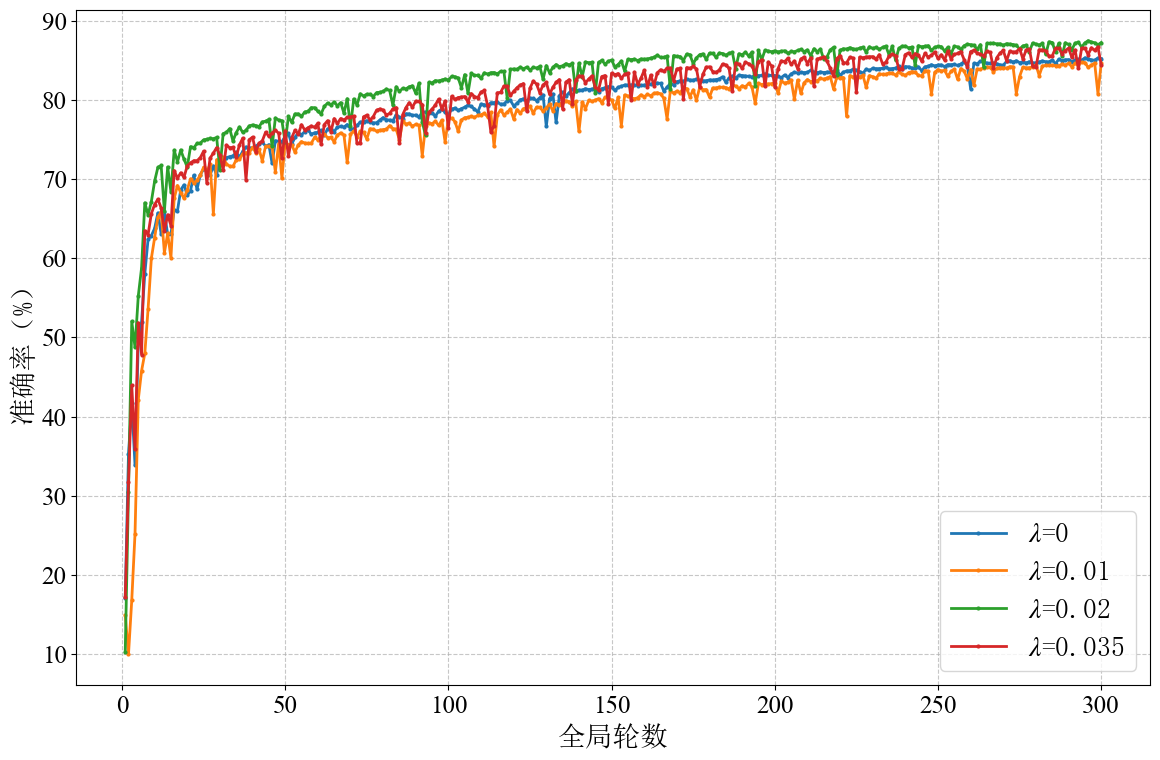

In [4]:

# 使用示例
if __name__ == "__main__":
    # 主目录路径
    main_dir = '/home/ypguo/async-FL/lambda_PK'
    
    # 调用函数生成图表
    result = plot_federated_learning_performance_lambda(
        main_dir=main_dir,
        max_time=60,  # 60分钟
        total_rounds=300,
        save_epoch_plot=True,
        save_time_plot=True,
        fig_size=(12, 8),
        dpi=150,
        dataset_name="Fashion-MNIST",
        dir_alpha="0.1"
    )
    
    # 输出加载情况总结
    print(f"\n成功加载的算法: {len(result['loaded_algorithms'])}")
    print(f"跳过的算法: {len(result['skipped_algorithms'])}")
    